In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

In [2]:
def cohen_glass_hedges(x,y):
    nx = len(x)
    ny = len(y)
    pstdnmr = (nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)   # (n-1)(var1+var2)
    pstddnm = nx + ny - 2                                   # (n-1)*2
    pstd = (pstdnmr / pstddnm)**(0.5)
    cohen = (x.mean() - y.mean()) / pstd
    glass = (x.mean() - y.mean()) / x.std(ddof=1)
    hedges = cohen * (1 - 3/(4 * (nx+ny) - 9) )             # cohen * (1-3/(8*n-9))
    return (cohen, glass, hedges)

In [3]:
w = pd.read_csv('ws.csv')

In [ ]:
w.id = w.id.str.replace('w', '')

In [5]:
wm = w.melt(id_vars=['Index', 'id', 'group', 'time', 'rank', 'total'], 
            value_vars=w.columns[6:],
            var_name='step',
            value_name='val')

In [7]:
total2 = pd.DataFrame(99.5, columns=range(1,4), index=range(1, 39))
total2.loc[:,3] = np.append(w.loc[:39,"1":].agg('mean').values, w.loc[40:,"1":].agg('mean').values)
total2.loc[:19,2] = 0
total2.loc[20:,2] = 1
total2.loc[:19,1] = range(1,20)
total2.loc[20:,1] = range(1,20)
total2.columns = ['step', 'time', 'avg2']

In [78]:
total2J = pd.DataFrame(99.5, columns=range(1,4), index=range(1, 39))
total2J.loc[:,3] = np.append(w.loc[(w.time=='initial') & (w.group=='J'), '1':].agg('mean').values,
                             w.loc[(w.time=='final') & (w.group=='J'), '1':].agg('mean').values)
total2J.loc[:19,2] = 0
total2J.loc[20:,2] = 1
total2J.loc[:19,1] = range(1,20)
total2J.loc[20:,1] = range(1,20)
total2J.columns = ['step', 'time', 'avg2']

In [8]:
wmf=wm.copy()
wmf['avg'] = wmf['total']/19
wmf[['Index', 'id', 'rank', 'total', 'step', 'val']] = wmf[['Index', 'id', 'rank','total', 'step', 'val']].astype(float)

In [86]:
AnovaRM(data=wm, depvar='val',
                 subject='id',
                 within=['time', 'step']).fit().summary()
# Two-way repeated-measures ANOVA, fully within design

,F Value,Num DF,Den DF,Pr > F
time,0.6578,1.0000,39.0000,0.4223
step,1.8220,18.0000,702.0000,0.0196
time:step,0.9587,18.0000,702.0000,0.5065


In [91]:
AnovaRM(data=wm.loc[wm.group=='J'], depvar='val',
                 subject='id',
                 within=['time', 'step']).fit().summary()
# Two-way repeated-measures ANOVA, fully within design

,F Value,Num DF,Den DF,Pr > F
time,3.6697,1.0000,15.0000,0.0747
step,1.0036,18.0000,270.0000,0.4558
time:step,0.7937,18.0000,270.0000,0.7074


In [96]:
model = smf.ols('val ~ time * step', data=wm)
print(anova_lm(model.fit(), typ=2))
# Two-way ANOVA, fully between design
# No random effects, just fixed effects
# No linear mixed model equivalent, just linear regression

              sum_sq      df         F    PR(>F)
time        0.125289     1.0  2.703449  0.100344
step        1.360711    18.0  1.631162  0.045635
time:step   0.638223    18.0  0.765074  0.743213
Residual   68.682275  1482.0       NaN       NaN


In [97]:
model2 = smf.ols('val ~ time * step', data=wm.loc[wm.group=='J'])
print(anova_lm(model2.fit(), typ=2))
# Two-way ANOVA, fully between design
# No random effects, just fixed effects
# No linear mixed model equivalent, just linear regression

              sum_sq     df          F    PR(>F)
time        1.061954    1.0  15.003439  0.000120
step        1.238083   18.0   0.971767  0.491093
time:step   0.818180   18.0   0.642187  0.867013
Residual   40.345006  570.0        NaN       NaN


In [ ]:
ss_array = []

ss_array = ss_array + [model.fit().centered_tss]
# total sum of squares = total variation

ss_array = ss_array + [model.fit().ssr]
# residual sum of squares = SSError = within group variation

ss_array = ss_array + [model.fit().ess]
# explained sum of squares = TSS - SSR = SStime + SSstep + SSinteraction

ss_array = ss_array + [model.fit().centered_tss - smf.ols('val ~ time', data=wm).fit().ssr]
# tss - ssr of a model which has only one factor
# = explained sum of squares of that model
# = variation due to that component

ss_array = ss_array + [model.fit().centered_tss - smf.ols('val ~ step', data=wm).fit().ssr]
# same for the other component

ss_array = ss_array + [model.fit().ess - smf.ols('val ~ step + time', data=wm).fit().ess]
# explained sum of squares of full model - 
# explained sum of squares of no interactions model =
# sum of squares of interaction

ss_array

[np.float64(70.80649894736842),
 np.float64(68.682275),
 np.float64(2.124223947368421),
 np.float64(0.12528947368420518),
 np.float64(1.3607114473684305),
 np.float64(0.6382230263157993)]

In [ ]:
smf.mixedlm('val ~ time', wm, groups=wm['id'], vc_formula={'step' : '1', }).fit().summary()

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:             MixedLM  Dependent Variable:  val     
No. Observations:  1520     Method:              REML    
No. Groups:        40       Scale:               0.0436  
Min. group size:   38       Log-Likelihood:      191.6585
Max. group size:   38       Converged:           Yes     
Mean group size:   38.0                                  
---------------------------------------------------------
                Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.628    0.012 54.549 0.000  0.606  0.651
time[T.initial] 0.018    0.011  1.695 0.090 -0.003  0.039
step Var        0.003    0.005                           
=========================================================

"""

In [92]:
smf.mixedlm('val ~ time', wm.loc[wm.group=='J'],
            groups=wm.loc[wm.group=='J', 'id'],
            vc_formula={'step' : '1', }).fit().summary()

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:             MixedLM  Dependent Variable:  val     
No. Observations:  608      Method:              REML    
No. Groups:        16       Scale:               0.0683  
Min. group size:   38       Log-Likelihood:      -57.5403
Max. group size:   38       Converged:           Yes     
Mean group size:   38.0                                  
---------------------------------------------------------
                Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.628    0.018 34.258 0.000  0.592  0.663
time[T.initial] 0.084    0.021  3.943 0.000  0.042  0.125
step Var        0.002    0.005                           
=========================================================

"""

In [13]:
smf.mixedlm('val ~ time * step', wm, groups=wm['id']).fit().summary().tables[0]

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,0,1,2,3
0,Model:,MixedLM,Dependent Variable:,val
1,No. Observations:,1520,Method:,REML
2,No. Groups:,40,Scale:,0.0433
3,Min. group size:,38,Log-Likelihood:,127.8343
4,Max. group size:,38,Converged:,Yes
5,Mean group size:,38.0,,


In [95]:
smf.mixedlm('val ~ time * step',
            wm.loc[wm.group=='J'],
            groups=wm.loc[wm.group=='J', 'id']).fit().summary().tables[0]

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,0,1,2,3
0,Model:,MixedLM,Dependent Variable:,val
1,No. Observations:,608,Method:,REML
2,No. Groups:,16,Scale:,0.0690
3,Min. group size:,38,Log-Likelihood:,-104.6612
4,Max. group size:,38,Converged:,Yes
5,Mean group size:,38.0,,


In [14]:
st.ttest_rel(w.loc[:39,'total'],w.loc[40:,'total'])
# t-test for subject averages (40 initial vs 40 final)

TtestResult(statistic=np.float64(0.8110552079799727), pvalue=np.float64(0.42225619346826915), df=np.int64(39))

In [15]:
st.ttest_rel(w.drop(w.loc[w.group=='B'].index).loc[w.time=='initial','total'],
             w.drop(w.loc[w.group=='B'].index).loc[w.time=='final','total'])
# t-test just for group J

TtestResult(statistic=np.float64(1.9156466397838643), pvalue=np.float64(0.07467159245888627), df=np.int64(15))

In [16]:
cohen_glass_hedges(w.loc[:39,'total'],w.loc[40:,'total'])[0]

np.float64(0.18959325118601736)

In [17]:
st.levene(w.loc[:39,'total'],w.loc[40:,'total'])

LeveneResult(statistic=np.float64(0.3694733109378813), pvalue=np.float64(0.5450572682539253))

In [18]:
st.ttest_rel(total2.loc[total2.time == 0, 'avg2'], total2.loc[total2.time == 1, 'avg2'])
# t-test for step averages (19 initial vs 19 final)

TtestResult(statistic=np.float64(1.879781237498926), pvalue=np.float64(0.0764245698710106), df=np.int64(18))

In [19]:
cohen_glass_hedges(total2.loc[total2.time == 0, 'avg2'], total2.loc[total2.time == 1, 'avg2'])[0]

np.float64(0.4873572838169839)

In [20]:
st.levene(total2.loc[total2.time == 0, 'avg2'], total2.loc[total2.time == 1, 'avg2'])

LeveneResult(statistic=np.float64(0.5607305102405724), pvalue=np.float64(0.4588309980246388))

In [21]:
st.ttest_rel(wm.loc[wm.time=='initial', 'val'],wm.loc[wm.time=='final', 'val'])
# t-test for all the values

TtestResult(statistic=np.float64(1.6716912617087243), pvalue=np.float64(0.09499739779965104), df=np.int64(759))

In [22]:
cohen_glass_hedges(wm.loc[wm.time=='initial', 'val'],wm.loc[wm.time=='final', 'val'])[0]

np.float64(0.08414908416442146)

In [23]:
st.levene(wm.loc[wm.time=='initial', 'val'],wm.loc[wm.time=='final', 'val'])

LeveneResult(statistic=np.float64(6.647265200987271), pvalue=np.float64(0.010024318510076386))

In [80]:
st.ttest_rel(total2J.loc[total2J.time == 0, 'avg2'], total2J.loc[total2J.time == 1, 'avg2'])
# t-test for group J and step averages (19 initial vs 19 final)

TtestResult(statistic=np.float64(4.833532338151383), pvalue=np.float64(0.0001332838720244645), df=np.int64(18))

In [81]:
cohen_glass_hedges(total2J.loc[total2J.time == 0, 'avg2'], total2J.loc[total2J.time == 1, 'avg2'])[0]

np.float64(1.3989525234278257)

In [ ]:
st.levene(total2J.loc[total2J.time == 0, 'avg2'], total2J.loc[total2J.time == 1, 'avg2'])

LeveneResult(statistic=np.float64(0.10261409216437067), pvalue=np.float64(0.7505668760150427))

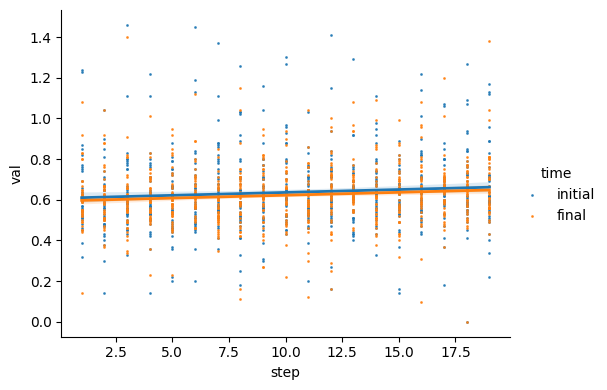

In [24]:
sns.lmplot(wmf.drop(wmf.loc[wmf.val > 1.5].index), x='step', y='val', hue ='time',            
           scatter_kws={"s": 1}, line_kws={"lw": 2}, 
           height=4, aspect=1.33)

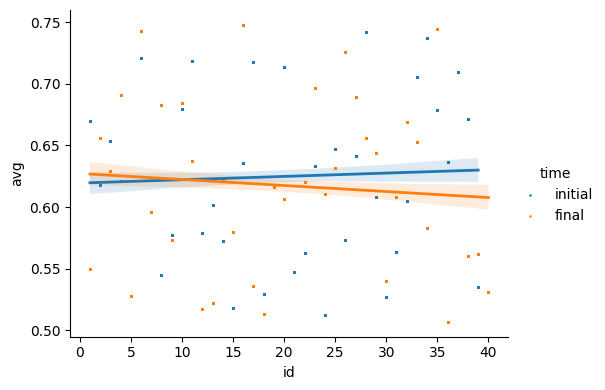

In [25]:
sns.lmplot(wmf.loc[wmf.avg<0.75], x='id', y='avg', hue ='time',            
           scatter_kws={"s": 1}, line_kws={"lw": 2}, 
           height=4, aspect=1.33)

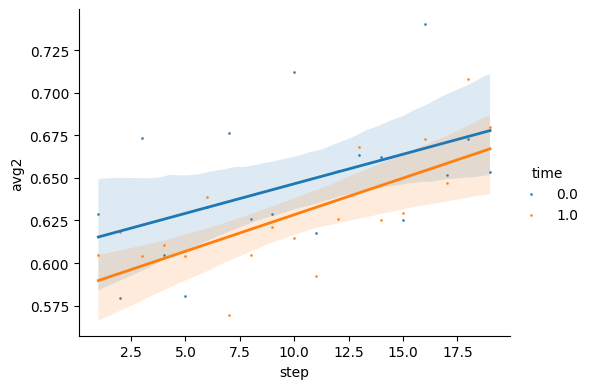

In [84]:
sns.lmplot(total2, x='step', y='avg2', hue ='time',            
           scatter_kws={"s": 1}, line_kws={"lw": 2}, 
           height=4, aspect=1.33)

<Axes: xlabel='step', ylabel='val'>

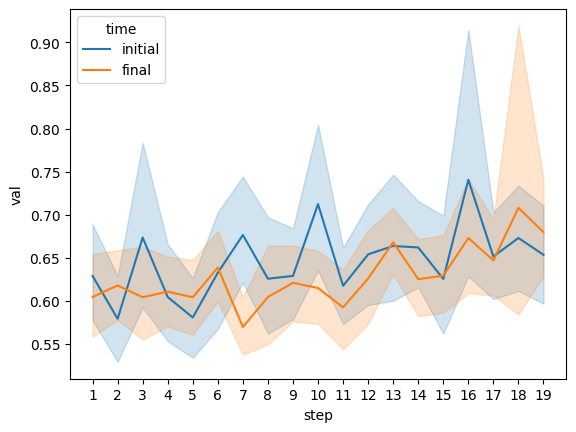

In [27]:
sns.lineplot(wm, x='step', y='val', hue ='time')

<Axes: xlabel='step', ylabel='val'>

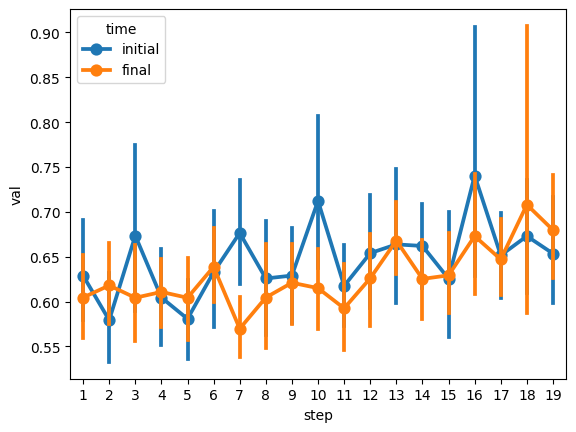

In [28]:
sns.pointplot(wm, x="step", y="val", hue="time")

<Axes: xlabel='time', ylabel='total'>

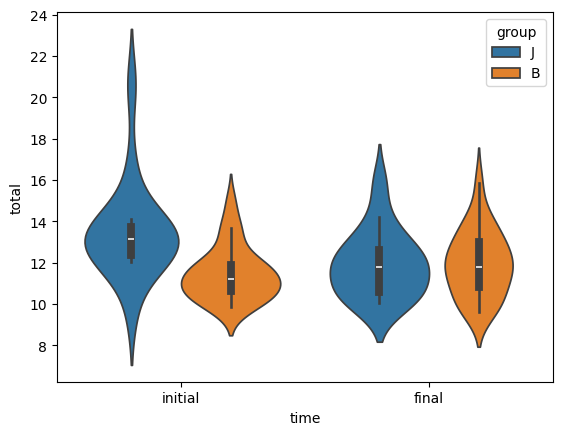

In [29]:
sns.violinplot(w, x="time", y="total", hue='group')

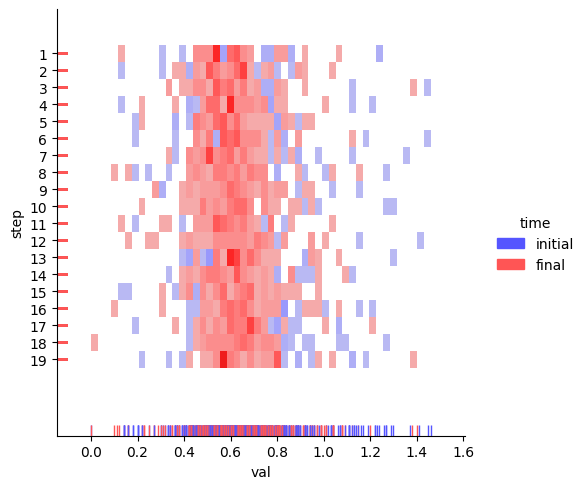

In [30]:
sns.displot(wm.drop(wm.loc[wm.val > 1.5].index), x='val', y='step', hue='time', rug='True', palette='seismic', legend=True)

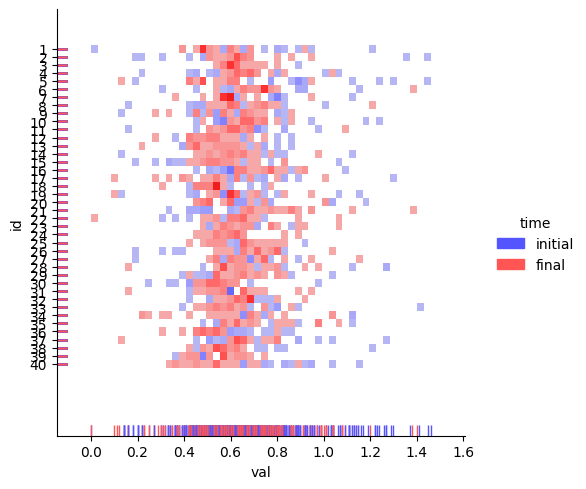

In [31]:
sns.displot(wm.drop(wm.loc[wm.val > 1.5].index), x='val', y='id', hue='time', rug='True', palette='seismic', legend=True)